<a href="https://colab.research.google.com/github/kowshik-ds/DATA-SCIENCE-TAKS/blob/main/Zomato_Basic_Requirement_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Restaurant and Review Data Analysis

Goal: Analyze restaurant and review data to extract insights on ratings, cuisines, location preferences and factors affecting ratings.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# To show charts clearly
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load Dataset

In [3]:
# Upload zomato.csv / zomato(1).csv in Colab Files section before running

file_name = '/content/zomato.csv'   # change to 'zomato.csv' if your file name is zomato.csv
df = pd.read_csv(file_name)

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


## 3. Basic Dataset Check

In [4]:
print('Rows and Columns:', df.shape)
print('\nColumn Names:')
print(df.columns)

df.info()

Rows and Columns: (28399, 13)

Column Names:
Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28399 entries, 0 to 28398
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      28395 non-null  object
 1   name                         28396 non-null  object
 2   online_order                 28396 non-null  object
 3   book_table                   28381 non-null  object
 4   rate                         24372 non-null  object
 5   votes                        28375 non-null  object
 6   phone                        27829 non-null  object
 7   location                     28359 non-null  object
 8   rest_type                    28240 non-null  object

## 4. Data Cleaning
Handle duplicate rows, missing values, rating text, and cost currency format.

In [5]:
# Check missing values
df.isnull().sum()

,0
address,4
name,3
online_order,3
book_table,18
rate,4027
votes,24
phone,570
location,40
rest_type,159
dish_liked,14807


In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

# Clean rating column: convert values like '4.1/5' into 4.1
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False).str.strip()
df['rate'] = df['rate'].replace(['NEW', '-', 'nan'], pd.NA)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column: convert values like '1,200' into 1200
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False).str.strip()
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].replace('nan', pd.NA)
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Clean votes column
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# Fill important text missing values
for col in ['location', 'cuisines', 'rest_type', 'listed_in(type)']:
    df[col] = df[col].fillna('Unknown')

# Remove rows where important numeric values are missing
df = df.dropna(subset=['rate', 'approx_cost(for two people)', 'votes'])

print('Cleaned dataset shape:', df.shape)
df.head()

Cleaned dataset shape: (16336, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775.0,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787.0,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918.0,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88.0,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166.0,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet


## 5. Cuisine vs Rating
Find cuisines with the highest average ratings.

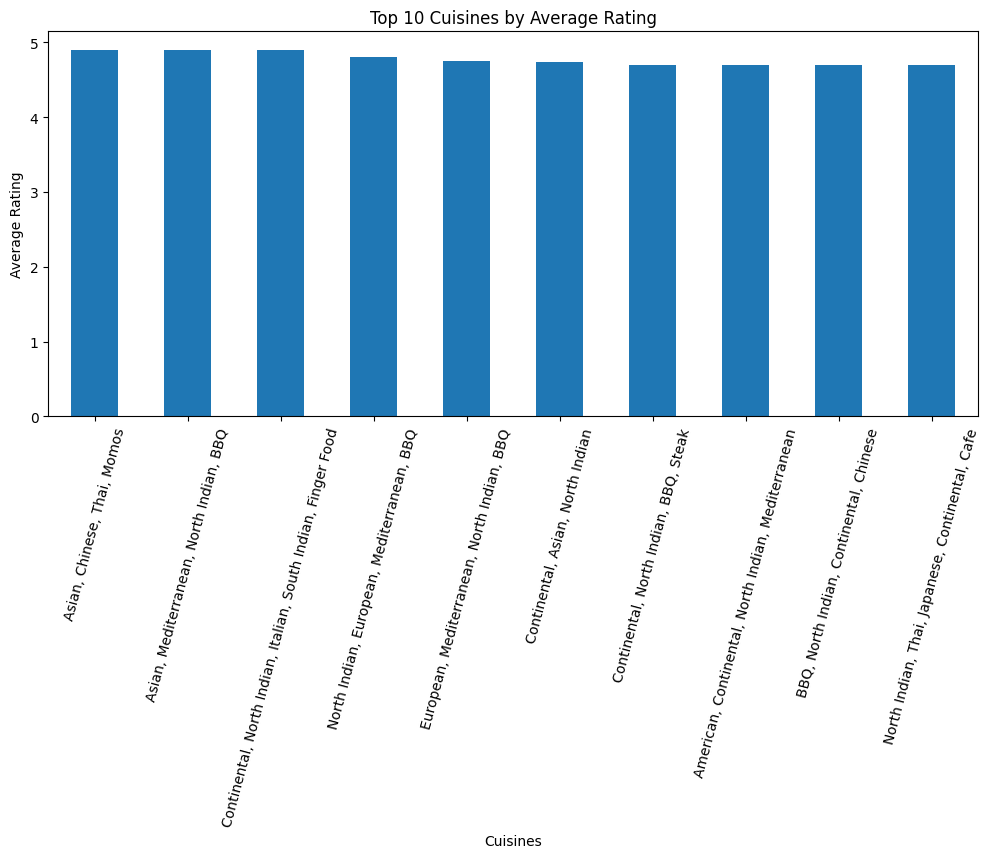

In [7]:
cuisine_rating = df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
cuisine_rating.plot(kind='bar')
plt.title('Top 10 Cuisines by Average Rating')
plt.xlabel('Cuisines')
plt.ylabel('Average Rating')
plt.xticks(rotation=75)
plt.show()

## 6. Location Hotspots
Find locations with the highest number of restaurants.

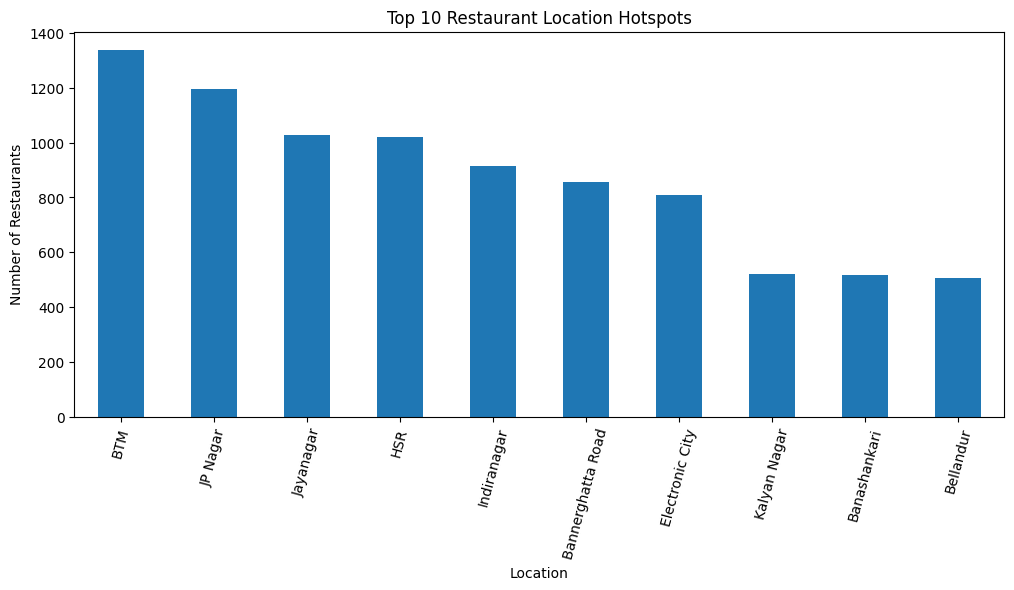

In [8]:
location_hotspots = df['location'].value_counts().head(10)

plt.figure(figsize=(12, 5))
location_hotspots.plot(kind='bar')
plt.title('Top 10 Restaurant Location Hotspots')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=75)
plt.show()

## 7. Price vs Rating
Check the relationship between cost for two people and rating.

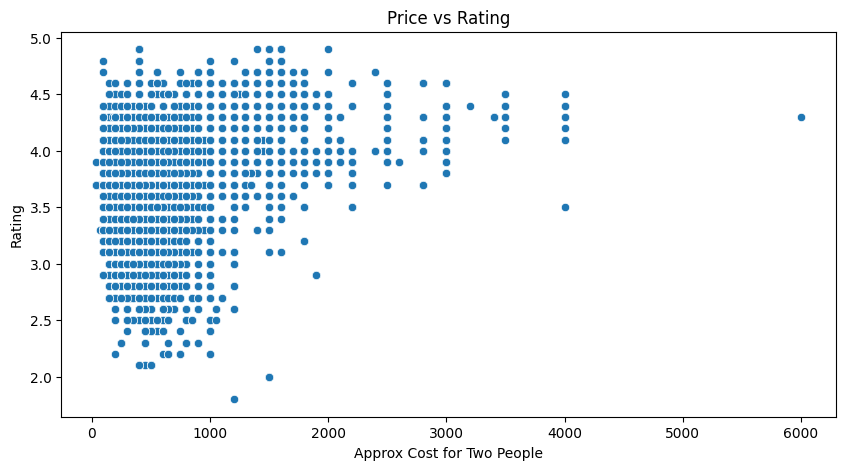

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title('Price vs Rating')
plt.xlabel('Approx Cost for Two People')
plt.ylabel('Rating')
plt.show()

## 8. Heatmap
Show relationship between rating, votes, and cost.

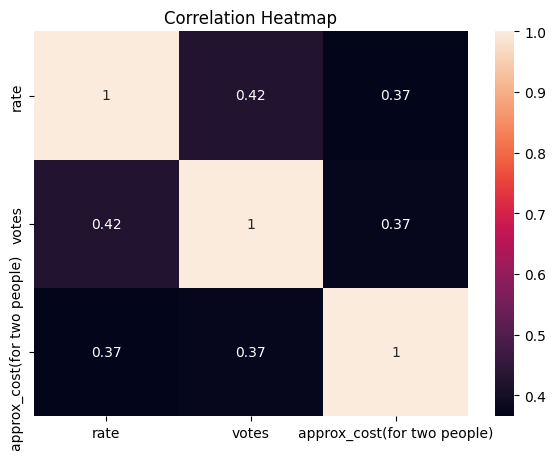

In [10]:
numeric_cols = df[['rate', 'votes', 'approx_cost(for two people)']]

plt.figure(figsize=(7, 5))
sns.heatmap(numeric_cols.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

## 9. WordCloud for Popular Cuisines

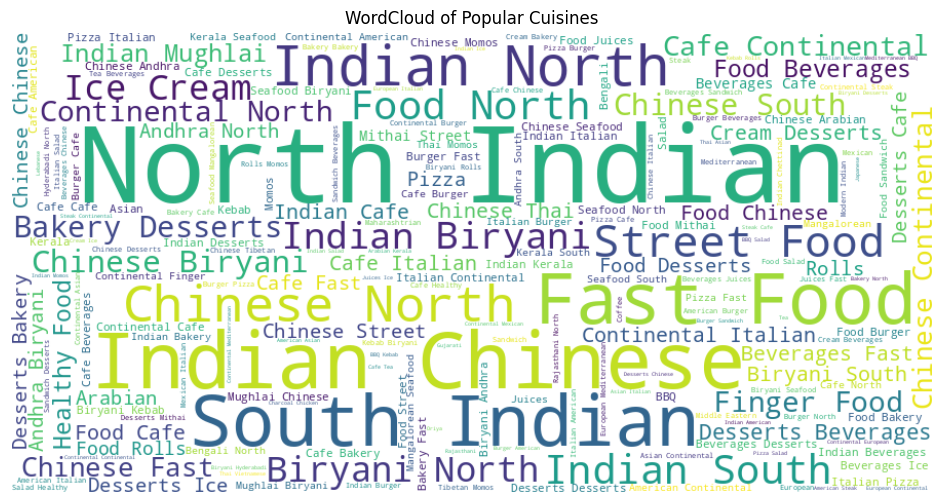

In [11]:
text = ' '.join(df['cuisines'].dropna().astype(str))

wordcloud = WordCloud(width=900, height=450, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Popular Cuisines')
plt.show()

## 10. Key Insights

1. Restaurant concentration is higher in a few major locations, showing clear location hotspots.
2. Some cuisines have better average ratings than others, which helps identify customer-preferred cuisine categories.
3. Price and rating do not always increase together; expensive restaurants are not automatically higher rated.
4. Votes are useful because restaurants with more votes usually give more reliable rating signals.
5. Cuisine and location together strongly influence restaurant visibility and customer preference.

## 11. Recommendations for Alfido Tech Style Platform

1. Partner with high-rated restaurants from top-performing cuisine categories.
2. Promote restaurants located in major hotspot areas to increase user engagement.
3. Create cuisine-based recommendation sections such as North Indian, Chinese, Cafe, and Fast Food.
4. Use both rating and votes for restaurant ranking, not rating alone.
5. Provide budget-based filters because price does not always guarantee better rating.

## 12. Save Cleaned Dataset

In [ ]:
df.to_csv('zomato_cleaned.csv', index=False)
print('Cleaned dataset saved as zomato_cleaned.csv')